In [20]:
import sys
import os


import torch
from torch import nn
from torch.nn import functional as F


import wandb
import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from torch.utils.data import DataLoader
from xaikd.utils import metrics, constants
from xaikd import models, datasets

from contextlib import nullcontext

from datetime import datetime

from matplotlib import colormaps

from torchvision import transforms

from collections import OrderedDict

from datetime import datetime

from matplotlib.ticker import StrMethodFormatter

from matplotlib import ticker

from functools import partial

In [22]:
api = wandb.Api()

In [23]:
PROJECT = "p16i/xaikd-s40-mobilenet-variants"
GROUP = "main-experiments"

In [27]:
def read_data(
    teacher, student,
    dataset_name,
    dataset_variant,
    policy,
    training_size=1.0,
    verbose=False,
    additional_query=dict()
):

    arr_datasets = [dataset_name]
    num_seeds = 3
      
    
    if policy == "ce_only":
        lambda_task = 1
        lambda_kd = 0
        policy = "nothing"
    elif policy == "kd_only":
        lambda_task = 0
        lambda_kd = 1
        policy = "nothing"
    else:
        lambda_task = 0
        lambda_kd = 1
        
    if policy == "fitnet":
        policy = resolve_fitnet(teacher, verbose=verbose)
 
    runs = api.runs(
        PROJECT,
        {
        "$and": [
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.dataset": {"$in": arr_datasets}},
            {"config.dataset-variant": dataset_variant},
            {"config.training_size": training_size},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"group": GROUP},
            *additional_query
        ]
        }
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        if not "arr_metrics"in run.summary:
            print(f">> bad run config (id={run.id}")

            count += 1
            return run
            continue

        
        best_val_acc = run.summary["arr_metrics"]["val_acc"][-1]
    
        best_train_acc = run.summary["arr_metrics"]["train_acc"][-1]


        rows.append(
            dict(
                val_acc=best_val_acc, 
                train_acc=best_train_acc,
                teacher_acc=run.summary["teacher_acc"],
                run_id=run.id,
                **run.config
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    np.testing.assert_allclose(
        df.shape[0],
        len(arr_datasets) * num_seeds,
        err_msg=f"teacher={teacher},policy={policy} (lambda_kd={lambda_kd},lambda_task={lambda_task})"
    )
    
    return df
  
_df = read_data(
    
    teacher="imagenet-mobilenetl-tv",
    
    dataset_name = "imagenet-butterfly",
    dataset_variant="spurious-threespurious--1.0",

    student="student-mobilenets",

    policy="basis-rotation:pca--uncentered",
    training_size=1.0,

    verbose=True,
)

_df

we have 3 runs


,val_acc,train_acc,teacher_acc,run_id,lr,seed,epochs,layers,policy,dataset,...,training_size,dataset-variant,last_layer_policy,enable_checkpointing,wandb-experiment-group,wandb_experiment_group,parameter_partition_mode,finetuning_with_layer_loss,default-lambda-layer-config,default_lambda_layer_config
0,0.866667,0.925232,0.93,cf8q75ds,0.0005,3,100,None,basis-rotation:pca--uncentered,imagenet-butterfly,...,1,spurious-threespurious--1.0,kd,True,main-experiments,main-experiments,@0,True,imagenet-spurious,imagenet-spurious
1,0.890000,0.925491,0.93,4asmrbw1,0.0005,2,100,None,basis-rotation:pca--uncentered,imagenet-butterfly,...,1,spurious-threespurious--1.0,kd,True,main-experiments,main-experiments,@0,True,imagenet-spurious,imagenet-spurious
2,0.883333,0.930785,0.93,v8y5s3op,0.0005,1,100,None,basis-rotation:pca--uncentered,imagenet-butterfly,...,1,spurious-threespurious--1.0,kd,True,main-experiments,main-experiments,@0,True,imagenet-spurious,imagenet-spurious


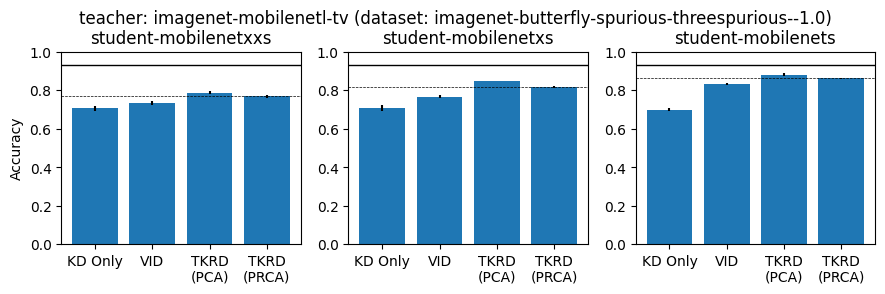

In [37]:
def alias(name):
        __dd = {
#             "basis-identity:random--uncentered": "Random Subspace",
#             "basis-identity:pca--uncentered": "TKRD-PCA-id",
            "basis-rotation:pca--uncentered": "TKRD\n(PCA)",

#             "basis-identity:prca-sortabs--uncentered": "TKRD-PRCA-id",
            "basis-rotation:prca-sortabs--uncentered": "TKRD\n(PRCA)",

#             "basis-identity:pcalookahead--uncentered": "TKRD-AH",
#             "basis-identity:prca-sortabs--uncentered": "RCM (Ours)",
            "vid": "VID",
            "attention-transfer": "AT",
            "fitnet": "FitNet",
            "nothing": "KD Only",
            "kd_only": "KD Only",
            "ce_only": "CE Only",
            "vkd": "VkD",
            "vkd-modified": "Vkd (Mod.)"
        }
        return __dd.get(name, name)
    
def viz(
    
    dataset_name,
    dataset_variant,
    teacher="imagenet-mobilenetl-tv",
    arr_students=[
        "student-mobilenets",   
        "student-mobilenetxs",   
        "student-mobilenetxxs",   
    ],
    arr_policies=[
        
        "kd_only",
        "vid",
#         "attention-transfer",
#         "spkd",
#         "vkd",
        "basis-rotation:pca--uncentered",
        "basis-rotation:prca-sortabs--uncentered",

    ]
):
    ncols = len(arr_students)

    training_size = 1.0
    variant_slug = "clean" if dataset_variant == "" else dataset_variant

    plt.figure(figsize=(3.5*ncols, 2.5))
    plt.suptitle(f"teacher: {teacher} (dataset: {dataset_name}-{variant_slug})", y=1.05)
    
    xticks = np.arange(len(arr_policies))
    
    for six, student in enumerate(arr_students):
        plt.subplot(1, ncols, six+1)

        if ("resnet18" in teacher or "vgg" in teacher) and "mobilenets" in student:
            continue
        stats = np.zeros((len(arr_policies), 2))
    
        for pix, policy in enumerate(arr_policies):
#             if student in ["student-mobilenetxs", "student-mobilenetxxs"] \
#                 and not policy in [
#                     "vid", "basis-rotation:pca--uncentered",
#         "basis-rotation:prca-sortabs--uncentered", 
#                 ]:
#                     continue
            _df = read_data(
                teacher=teacher,
                dataset_name=dataset_name,
                student=student,
                policy=policy,
                dataset_variant=dataset_variant,
                training_size=training_size,
            )
            
            if pix == 0:
                teacher_acc = _df["teacher_acc"].values[0]
            
            val_acc = _df["val_acc"]
            stats[pix, :] = val_acc.mean(), val_acc.sem()
        
        
        plt.title(f"{student}")
        
        plt.axhline(teacher_acc, ls="-", lw=1, color="k")
        plt.bar(xticks, stats[:, 0], yerr=stats[:, 1])
        plt.axhline(stats[-1, 0], ls="--", lw=0.5, color="k")
        plt.xticks(xticks, list(map(alias, arr_policies)), rotation=0)
    
        plt.ylim([0, 1])
        if six == 0:
            plt.ylabel("Accuracy")
    
        
viz(
    teacher="imagenet-mobilenetl-tv",
    dataset_name="imagenet-butterfly",
    dataset_variant="spurious-threespurious--1.0",
    arr_students=[
        "student-mobilenetxxs",
        "student-mobilenetxs",    
        "student-mobilenets",
    ]
)

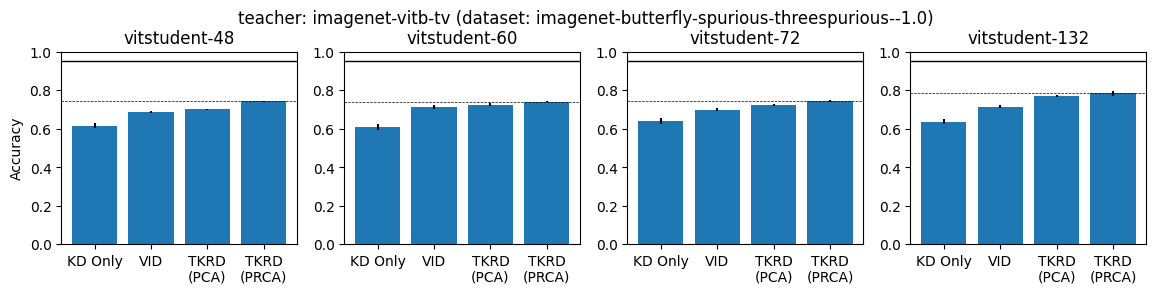

In [36]:
viz(
    teacher="imagenet-vitb-tv",
    dataset_name="imagenet-butterfly",
    dataset_variant="spurious-threespurious--1.0",
    arr_students=[
            "vitstudent-48",
            "vitstudent-60",
            "vitstudent-72",
            "vitstudent-132",
    ]
)